In [62]:
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from torchvision import datasets, transforms
from PIL import Image
import torch
import os
from BIMT_2D import BioMLP2D

In [89]:
model_type = "local"

In [96]:

json_file = json.load(open(f'results/manifold_json/{model_type}.json', 'r'))

json_file = dict(sorted(json_file.items(), key=lambda x: int(x[0])))

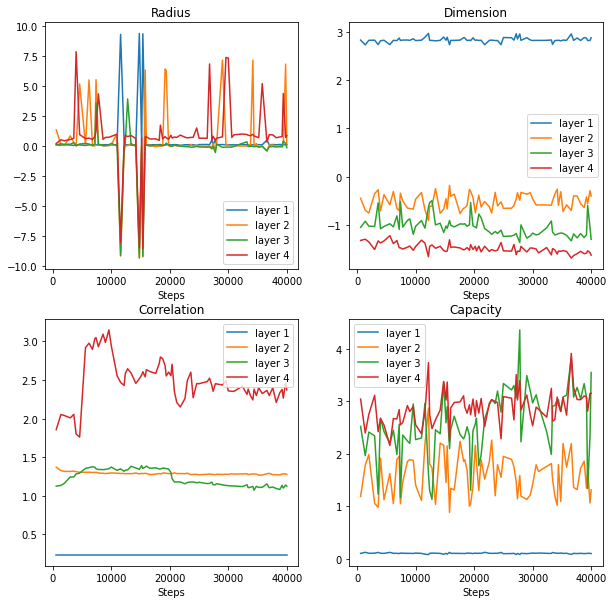

In [97]:
fig, ax = plt.subplots(2, 2, figsize=(10, 10))
properties = ['radius', 'dimension', 'correlation', 'capacity']
titles = ['Radius', 'Dimension', 'Correlation', 'Capacity']

for i, prop in enumerate(properties):
    layers = [[], [], [], []]
    keys = []
    for key, value in json_file.items():
        if value == {}:
            continue
        for j in range(4):
            if prop in ['radius', 'dimension']:
                layers[j].append(np.log(value[prop][j]) if j == 0 else np.log(value[prop][j]/value[prop][0]))
            else:
                layers[j].append(value[prop][j] if j == 0 else value[prop][j]/value[prop][0])
        keys.append(int(key))
    ax[i//2, i%2].plot(keys, layers[0], label='layer 1')
    ax[i//2, i%2].plot(keys, layers[1], label='layer 2')
    ax[i//2, i%2].plot(keys, layers[2], label='layer 3')
    ax[i//2, i%2].plot(keys, layers[3], label='layer 4')
    ax[i//2, i%2].set_title(titles[i])
    ax[i//2, i%2].legend()
    ax[i//2, i%2].set_xlabel('Steps')

fig.savefig(f'results/manifold_plots/{model_type}.jpg')

In [56]:
# Load MNIST test data
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
test_data = datasets.MNIST(root='./neural_manifolds_replicaMFT/mftma/data', train=False, download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=1000, shuffle=False)


100%|██████████| 9912422/9912422 [00:08<00:00, 1232685.44it/s]


Extracting ./neural_manifolds_replicaMFT/mftma/data/MNIST/raw/train-images-idx3-ubyte.gz to ./neural_manifolds_replicaMFT/mftma/data/MNIST/raw



100%|██████████| 28881/28881 [00:00<00:00, 24853445.59it/s]

Extracting ./neural_manifolds_replicaMFT/mftma/data/MNIST/raw/train-labels-idx1-ubyte.gz to ./neural_manifolds_replicaMFT/mftma/data/MNIST/raw



100%|██████████| 1648877/1648877 [00:00<00:00, 2041901.99it/s]


Extracting ./neural_manifolds_replicaMFT/mftma/data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./neural_manifolds_replicaMFT/mftma/data/MNIST/raw



100%|██████████| 4542/4542 [00:00<00:00, 8939713.17it/s]

Extracting ./neural_manifolds_replicaMFT/mftma/data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./neural_manifolds_replicaMFT/mftma/data/MNIST/raw



In [90]:

# Function to get PCA components and labels
def get_pca_components(model, data_loader):
    for images, labels in data_loader:
        output = model(images)
        pca = PCA(n_components=2)
        components = pca.fit_transform(output.detach().numpy())
        return components, labels.numpy()

# Function to plot PCA components
def plot_pca(components, labels, step):
    scatter = plt.scatter(components[:, 0], components[:, 1], c=labels, cmap='tab10')
    plt.title(f'PCA Decomposition - Step {step}')
    plt.colorbar(scatter, ticks=range(10), label='Digit')
    plt.savefig(f'results/pca_plots/{model_type}/pca_{step}.jpg')
    plt.close()




In [91]:
!ls

BIMT.py                          data
BIMT_2D.py                       manifold_analysis_correlation.py
BIMT_manifolds.ipynb             models
BIMT_manifolds.py                neural_manifolds_replicaMFT
MFTMA_VGG16_example.ipynb        res_pca
__pycache__                      res_tsne
alldata_dimension_analysis.py    results
analyse_data.ipynb               utils
analyze_pytorch.py


In [92]:
# Load models and create PCA plots
base_dir = f'models/{model_type}_cnn'
model_paths = sorted(os.listdir(base_dir), key=lambda x: int(x.split('-')[0]))
model = BioMLP2D(shp=[784, 100, 100, 10])
for model_path in model_paths:
    model.load_state_dict(torch.load(base_dir + "/" + model_path, map_location=torch.device('cpu')))
    components, labels = get_pca_components(model, test_loader)
    step = int(model_path.split('-')[0])
    plot_pca(components, labels, step)

# Create GIF
images = [Image.open(f'results/pca_plots/{model_type}/{img}') for img in sorted(os.listdir(f'results/pca_plots/{model_type}'), key=lambda x: int(x.split('_')[-1].split('.')[0]))]
images[0].save(f'results/pca_plots/videos/pca_{model_type}.gif', save_all=True, append_images=images[1:], loop=0, duration=200)

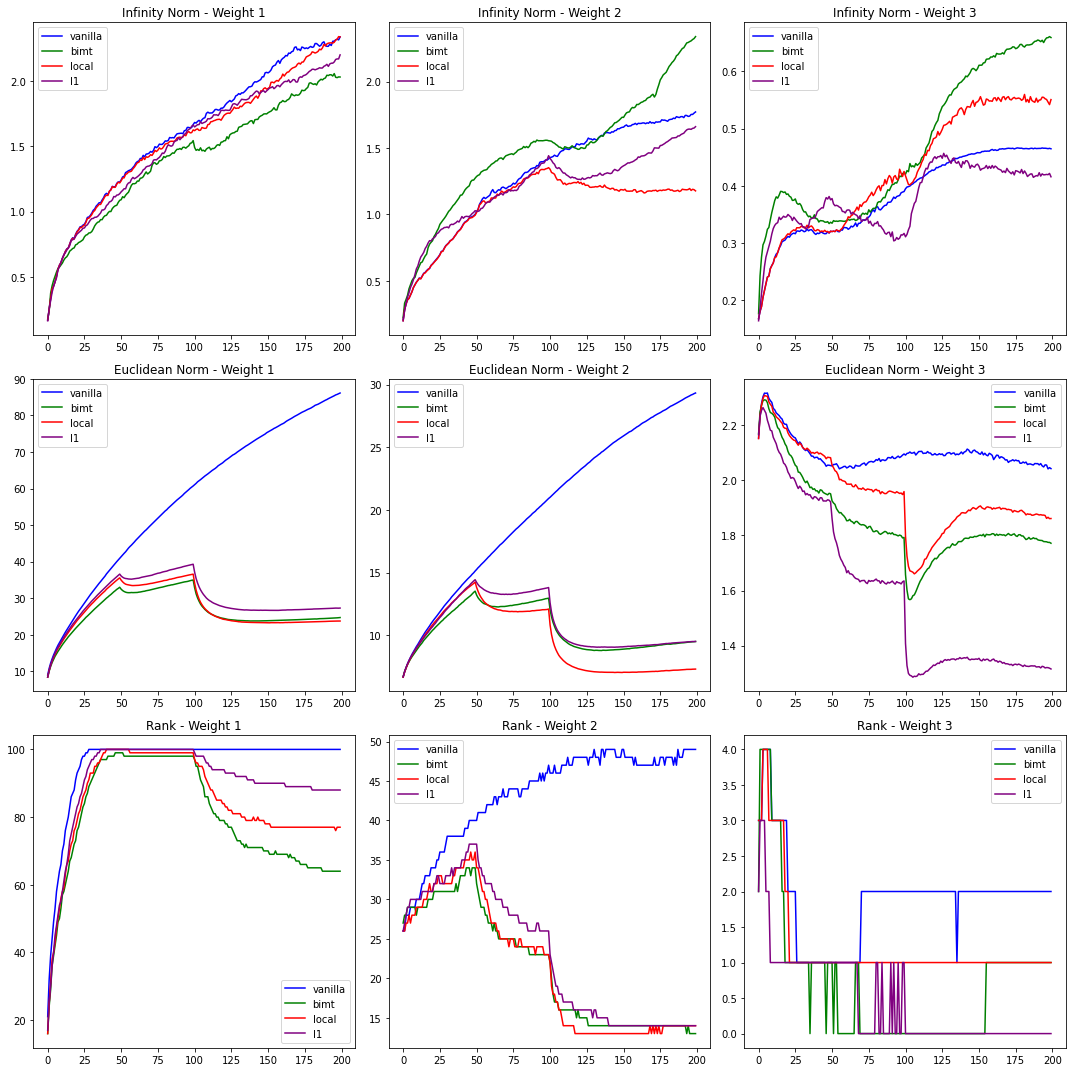

In [109]:
def get_LA(model, tol=1e-4):
    inf_norms, euc_norms, ranks = {}, {}, {}
    for name, param in model.named_parameters():
        if 'weight' in name and len(param.size()) == 2:  # Only consider weight matrices of linear layers
            norm = torch.norm(param.data, p=float('inf')).item()
            inf_norms[name] = norm
            norm = torch.norm(param.data).item()
            euc_norms[name] = norm
            weights = param.data.numpy()
            weights = weights.T @ weights 
            
            ranks[name] = (np.linalg.eigvalsh(weights) > 0.6).sum()
    return inf_norms, euc_norms, ranks

mlp = BioMLP2D(shp=(784,100,100,10))

fig, ax = plt.subplots(3, 3, figsize=(15, 15)) 
model_types = ['vanilla', 'bimt', 'local', 'l1']
colors = ['blue', 'green', 'red', 'purple'] # Different color for each model type

for model_idx, model_type in enumerate(model_types):
    paths = sorted(os.listdir(f'models/{model_type}_cnn'), key=lambda x: int(x.split('-')[0]))
    
    inf_norms_hist = {0:[], 1:[], 2:[]} # Initialize history dictionaries for norms
    euc_norms_hist = {0:[], 1:[], 2:[]}
    ranks_hist = {0:[], 1:[], 2:[]}

    for path in paths:
        mlp.load_state_dict(torch.load(f'models/{model_type}_cnn/{path}', map_location=torch.device('cpu')))
        inf_norms, euc_norms, ranks = get_LA(mlp)
        
        # Store history of norms
        for idx, (inf_norm, euc_norm, rank) in enumerate(zip(inf_norms.values(), euc_norms.values(), ranks.values())):
            inf_norms_hist[idx].append(inf_norm)
            euc_norms_hist[idx].append(euc_norm)
            ranks_hist[idx].append(rank)
    # Plot the norms
    for idx in range(3):
        ax[0, idx].plot(inf_norms_hist[idx], color=colors[model_idx], label=model_type)
        ax[0, idx].set_title(f'Infinity Norm - Weight {idx+1}')
        ax[0, idx].legend()
        
        ax[1, idx].plot(euc_norms_hist[idx], color=colors[model_idx], label=model_type)
        ax[1, idx].set_title(f'Euclidean Norm - Weight {idx+1}')
        ax[1, idx].legend()

        ax[2, idx].plot(ranks_hist[idx], color=colors[model_idx], label=model_type)
        ax[2, idx].set_title(f'Rank - Weight {idx+1}')
        ax[2, idx].legend()
plt.savefig('results/linear_algebra/norms.jpg')
plt.tight_layout()
plt.show()


In [ ]:
# Function to get rank of weight matrices
def get_rank(model):
    ranks = []
    for name, param in model.named_parameters():
        if 'weight' in name:
            ranks.append(np.linalg.matrix_rank(param.detach().numpy()))
    return ranks


mlp = BioMLP2D(shp=(784,100,100,10))

fig, ax = plt.subplots(3, figsize=(15, 10)) # 2 rows for 2 norms, 3 columns for 3 weights
model_types = ['vanilla', 'bimt', 'local', 'l1']
colors = ['blue', 'green', 'red', 'purple'] # Different color for each model type

for model_idx, model_type in enumerate(model_types):
    paths = sorted(os.listdir(f'models/{model_type}_cnn'), key=lambda x: int(x.split('-')[0]))
    
    rank_hist = {0:[], 1:[], 2:[]} # Initialize history dictionaries for norms

    for path in paths:
        mlp.load_state_dict(torch.load(f'models/{model_type}_cnn/{path}', map_location=torch.device('cpu')))
        ranks = get_infinity_norms(mlp)
        
        # Store history of norms
        for idx, (inf_norm, euc_norm) in enumerate(zip(inf_norms.values(), euc_norms.values())):
            inf_norms_hist[idx].append(inf_norm)
    
    # Plot the norms
    for idx in range(3):
        ax[idx].plot(inf_norms_hist[idx], color=colors[model_idx], label=model_type)
        ax[idx].set_title(f'Infinity Norm - Weight {idx+1}')
        ax[idx].legend()

plt.savefig('results/norms/norms.jpg')
plt.tight_layout()
plt.show()
